## IS547 Course Project

## Harmonizing Instrumental Climate Observations and Reported Severe Weather Events in Illinois (2010–2025)
### Jasmitha Duvvuru (jd56)

### How to Run the Notebook and Reproduce the Results
To reproduce the entire curation workflow and generate the final integrated dataset, the files must be organized exactly as shown below:

Before running this notebook, make sure the downloaded folder is unzipped. The jupyter notebook file should be in the same directory/folder as that of the Raw Data folder.

```
├── Raw Data/
│   ├── Climate Dataset1.csv
│   └── StormEvents_details/
│       ├── StormEvents_2010.csv
│       ├── StormEvents_2011.csv
│       ├── StormEvents_2012.csv
│       ├── StormEvents_2013.csv
│       ├── StormEvents_2014.csv
│       ├── StormEvents_2015.csv
│       ├── StormEvents_2016.csv
│       ├── StormEvents_2017.csv
│       ├── StormEvents_2018.csv
│       ├── StormEvents_2019.csv
│       ├── StormEvents_2020.csv
│       ├── StormEvents_2021.csv
│       ├── StormEvents_2022.csv
│       ├── StormEvents_2023.csv
│       ├── StormEvents_2024.csv
│       └── StormEvents_2025.csv
├── is547_course_project.ipynb          ← Main notebook (run this)
├── data_dictionary.md
├── README.md
├── Processed Data/                     ← Cleaned and final outputs folder
└── (other documentation files)
```

In [69]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

input_file = "Raw Data/Climate Dataset1.csv"
output_file = "ghcn_illinois_clean.csv"

stations = [
    "USW00094846", "USW00014819", "USW00014880", "USW00014923",
    "USW00014842", "USW00094870", "USW00003887", "USW00014834",
    "USW00013802", "USW00094822"
]

station_info = {
    "USW00094846": ("Chicago O'Hare Intl AP", "North"),
    "USW00014819": ("Chicago Midway AP", "North"),
    "USW00014880": ("Chicago Waukegan Rgnl AP", "North"),
    "USW00014923": ("Moline Quad City Intl AP", "Northwest"),
    "USW00014842": ("Peoria General Wayne A Downing Intl AP", "Central"),
    "USW00094870": ("Champaign Urbana Willard AP", "Central"),
    "USW00003887": ("Decatur AP", "Central"),
    "USW00014834": ("Joliet", "North-Central"),
    "USW00013802": ("Belleville SIU Rsch", "Southwest"),
    "USW00094822": ("Rockford Greater Rockford AP", "North")
}

print("Starting full curation pipeline...")

df = pd.read_csv(
    input_file,
    quotechar='"',
    on_bad_lines='skip',
    low_memory=False
)

print(f"Original rows: {len(df):,}")

# Filtering stations
df = df[df["STATION"].isin(stations)].copy()

# Safe column selection
keep_cols = ["STATION", "NAME", "DATE", "TMAX", "TMIN", "TAVG",
             "PRCP", "SNOW", "SNWD",
             "TMAX_ATTRIBUTES", "TMIN_ATTRIBUTES", "TAVG_ATTRIBUTES",
             "PRCP_ATTRIBUTES", "SNOW_ATTRIBUTES", "SNWD_ATTRIBUTES"]
keep_cols = [col for col in keep_cols if col in df.columns]
df = df[keep_cols].copy()

# Converting date
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# Handling trace precipitation
# 'T' = trace → treated as 0 for consistency
for col in ["PRCP", "SNOW", "SNWD"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("T", "0", regex=False)

# Converting all numeric columns
for col in ["TMAX", "TMIN", "TAVG", "PRCP", "SNOW", "SNWD"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Droping rows with no temperature data
df = df.dropna(subset=["TMAX", "TMIN"], how="all")

# Removing duplicates
df = df.drop_duplicates(subset=["STATION", "DATE"])

temp_cols = [col for col in ["TMAX", "TMIN", "TAVG"] if col in df.columns]
precip_cols = [col for col in ["PRCP", "SNOW", "SNWD"] if col in df.columns]
# Convert temperature from °F to °C
df[temp_cols] = (df[temp_cols] - 32) * 5 / 9

# Converting precipitation/snow from inches to millimeters
df[precip_cols] = df[precip_cols] * 25.4

# NOAA TAVG is inconsistent → recomputing if missing
df["TAVG"] = df["TAVG"].fillna((df["TMAX"] + df["TMIN"]) / 2)

print("\nData ranges after unit conversion:")
print(df[["TMAX", "TMIN", "TAVG", "PRCP", "SNOW"]].describe().round(2))

df = df[(df["TMAX"] < 60) & (df["TMIN"] > -50)]

# Flags reviewed but not used to preserve completeness
attr_cols = [col for col in df.columns if "ATTRIBUTES" in col]
df = df.drop(columns=attr_cols)

# Safe mapping
df["STATION_NAME"] = df["STATION"].map(lambda x: station_info.get(x, ("Unknown", "Unknown"))[0])
df["REGION"] = df["STATION"].map(lambda x: station_info.get(x, ("Unknown", "Unknown"))[1])

# Checking for mapping issues
if df["STATION_NAME"].isin(["Unknown"]).any():
    print("Warning: Some stations not mapped correctly")

# Adding time features
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month

# Cleaner season logic
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["SEASON"] = df["MONTH"].apply(get_season)

final_cols = ["STATION", "STATION_NAME", "REGION", "DATE", "YEAR", "MONTH", "SEASON",
              "TMAX", "TMIN", "TAVG", "PRCP", "SNOW", "SNWD"]
final_cols = [col for col in final_cols if col in df.columns]
df = df[final_cols].copy()

df = df.sort_values(["STATION", "DATE"]).reset_index(drop=True)

print(f"\nFinal cleaned rows: {len(df):,}")
print(df.head())

df.to_csv(output_file, index=False)
print(f"\nSaved clean, curated dataset → {output_file}")
print(" Includes: region + season + validated units (ready for integration)")

Starting full curation pipeline...
Original rows: 52,922

Data ranges after unit conversion:
           TMAX      TMIN      TAVG      PRCP      SNOW
count  52808.00  52789.00  52779.00  51972.00  26318.00
mean      16.90      6.17     11.53      2.60      2.28
std       11.83     10.69     11.07      7.64     14.67
min      -25.00    -36.11    -28.33      0.00      0.00
25%        7.22     -1.67      3.06      0.00      0.00
50%       18.33      6.67     12.22      0.00      0.00
75%       27.22     15.56     21.39      0.76      0.00
max       41.11     28.33     34.17    174.24    411.48

Final cleaned rows: 52,779
       STATION STATION_NAME   REGION       DATE  YEAR  MONTH  SEASON  \
0  USW00003887   Decatur AP  Central 2010-01-01  2010      1  Winter   
1  USW00003887   Decatur AP  Central 2010-01-02  2010      1  Winter   
2  USW00003887   Decatur AP  Central 2010-01-03  2010      1  Winter   
3  USW00003887   Decatur AP  Central 2010-01-04  2010      1  Winter   
4  USW00003887 

In [70]:
input_path = "Raw Data/StormEvents_details/*.csv"   # folder containing storm events data by years
output_file = "storm_events_all_clean.csv"

event_types = ["Winter Storm", "Blizzard", "Flood", "Excessive Heat"]

print("Starting multi-year Storm Events cleaning...")

files = glob.glob(input_path)

all_data = []

for file in files:
    print(f"\nProcessing: {file}")

    df = pd.read_csv(file, low_memory=False)

    # Filtering Illinois
    df = df[df["STATE"] == "ILLINOIS"].copy()

    # Filtering event types
    df = df[df["EVENT_TYPE"].isin(event_types)].copy()

    # Selecting columns
    keep_cols = [
        "STATE", "CZ_NAME", "EVENT_TYPE",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "DAMAGE_PROPERTY", "DAMAGE_CROPS",
        "INJURIES_DIRECT", "DEATHS_DIRECT"
    ]

    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols].copy()

    # Cleaning dates
    df["BEGIN_DATE_TIME"] = pd.to_datetime(df["BEGIN_DATE_TIME"], errors="coerce")
    df["END_DATE_TIME"] = pd.to_datetime(df["END_DATE_TIME"], errors="coerce")

    df = df.dropna(subset=["BEGIN_DATE_TIME", "END_DATE_TIME"])

    # Parsing damage
    def parse_damage(val):
        if pd.isna(val):
            return 0
        val = str(val).strip()
        if val == "" or val == "0":
            return 0

        multiplier = 1
        if val.endswith("K"):
            multiplier = 1_000
            val = val[:-1]
        elif val.endswith("M"):
            multiplier = 1_000_000
            val = val[:-1]
        elif val.endswith("B"):
            multiplier = 1_000_000_000
            val = val[:-1]

        try:
            return float(val) * multiplier
        except:
            return 0

    df["DAMAGE_PROPERTY"] = df["DAMAGE_PROPERTY"].apply(parse_damage)
    df["DAMAGE_CROPS"] = df["DAMAGE_CROPS"].apply(parse_damage)

    rows = []

    for _, row in df.iterrows():
        start = row["BEGIN_DATE_TIME"].date()
        end = row["END_DATE_TIME"].date()

        date_range = pd.date_range(start=start, end=end)

        for d in date_range:
            rows.append({
                "STATE": row["STATE"],
                "COUNTY": row["CZ_NAME"],
                "DATE": d,
                "EVENT_TYPE": row["EVENT_TYPE"],
                "DAMAGE_PROPERTY": row["DAMAGE_PROPERTY"],
                "DAMAGE_CROPS": row["DAMAGE_CROPS"],
                "INJURIES": row["INJURIES_DIRECT"],
                "DEATHS": row["DEATHS_DIRECT"]
            })

    df_daily = pd.DataFrame(rows)

    all_data.append(df_daily)

# Combining all years' files
print("\nCombining all years...")
final_df = pd.concat(all_data, ignore_index=True)

final_df["EVENT_FLAG"] = 1

final_df = final_df.groupby(
    ["STATE", "COUNTY", "DATE", "EVENT_TYPE"],
    as_index=False
).agg({
    "EVENT_FLAG": "max",
    "DAMAGE_PROPERTY": "sum",
    "DAMAGE_CROPS": "sum",
    "INJURIES": "sum",
    "DEATHS": "sum"
})

final_df = final_df.sort_values(["COUNTY", "DATE"])

print(f"Final dataset rows: {len(final_df):,}")
print(final_df.head())

final_df.to_csv(output_file, index=False)

print(f"\nSaved → {output_file}")
print("   Includes ALL years (2010–2025)")

Starting multi-year Storm Events cleaning...

Processing: Raw Data/StormEvents_details\StormEvents_2010.csv

Processing: Raw Data/StormEvents_details\StormEvents_2011.csv

Processing: Raw Data/StormEvents_details\StormEvents_2012.csv

Processing: Raw Data/StormEvents_details\StormEvents_2013.csv

Processing: Raw Data/StormEvents_details\StormEvents_2014.csv

Processing: Raw Data/StormEvents_details\StormEvents_2015.csv

Processing: Raw Data/StormEvents_details\StormEvents_2016.csv

Processing: Raw Data/StormEvents_details\StormEvents_2017.csv

Processing: Raw Data/StormEvents_details\StormEvents_2018.csv

Processing: Raw Data/StormEvents_details\StormEvents_2019.csv

Processing: Raw Data/StormEvents_details\StormEvents_2020.csv

Processing: Raw Data/StormEvents_details\StormEvents_2021.csv

Processing: Raw Data/StormEvents_details\StormEvents_2022.csv

Processing: Raw Data/StormEvents_details\StormEvents_2023.csv

Processing: Raw Data/StormEvents_details\StormEvents_2024.csv

Processin

In [71]:
# Loading cleaned GHCN file
df_ghcn = pd.read_csv("ghcn_illinois_clean.csv")

# Station → County mapping
station_to_county = {
    "USW00094846": "Cook",      # Chicago O'Hare
    "USW00014819": "Cook",      # Chicago Midway
    "USW00014880": "Lake",      # Waukegan
    "USW00094822": "Winnebago", # Rockford
    "USW00014923": "Rock Island", # Moline
    "USW00014842": "Peoria",    # Peoria
    "USW00094870": "Champaign", # Champaign-Urbana
    "USW00003887": "Macon",     # Decatur
    "USW00014834": "Will",      # Joliet
    "USW00013802": "St. Clair"  # Belleville
}

df_ghcn["COUNTY"] = df_ghcn["STATION"].map(station_to_county)

# Saving the updated file
df_ghcn.to_csv("ghcn_illinois_clean_with_county.csv", index=False)

print("Added COUNTY column!")
print(df_ghcn[["STATION", "STATION_NAME", "REGION", "COUNTY"]].drop_duplicates())

Added COUNTY column!
           STATION                            STATION_NAME         REGION  \
0      USW00003887                              Decatur AP        Central   
5830   USW00013802                     Belleville SIU Rsch      Southwest   
11563  USW00014819                       Chicago Midway AP          North   
17405  USW00014834                                  Joliet  North-Central   
17766  USW00014842  Peoria General Wayne A Downing Intl AP        Central   
23606  USW00014880                Chicago Waukegan Rgnl AP          North   
29428  USW00014923                Moline Quad City Intl AP      Northwest   
35268  USW00094822            Rockford Greater Rockford AP          North   
41112  USW00094846                  Chicago O'Hare Intl AP          North   
46956  USW00094870             Champaign Urbana Willard AP        Central   

            COUNTY  
0            Macon  
5830     St. Clair  
11563         Cook  
17405         Will  
17766       Peoria  
23606

In [72]:
# Loading the cleaned files
ghcn = pd.read_csv("ghcn_illinois_clean_with_county.csv")
storm = pd.read_csv("storm_events_all_clean.csv")

print(f"GHCN rows: {len(ghcn):,}")
print(f"Storm rows: {len(storm):,}")

# Normalizing county names for accurate matching
def normalize_county(name):
    if pd.isna(name):
        return ""
    name = str(name).strip().upper()
    name = name.replace("COUNTY", "").strip()
    return name

ghcn["COUNTY_NORM"] = ghcn["COUNTY"].apply(normalize_county)
storm["COUNTY_NORM"] = storm["COUNTY"].apply(normalize_county)

# Station to normalized county mapping
station_to_county = {
    "USW00094846": "COOK",
    "USW00014819": "COOK",
    "USW00014880": "LAKE",
    "USW00094822": "WINNEBAGO",
    "USW00014923": "ROCK ISLAND",
    "USW00014842": "PEORIA",
    "USW00094870": "CHAMPAIGN",
    "USW00003887": "MACON",
    "USW00014834": "WILL",
    "USW00013802": "ST. CLAIR"
}

ghcn["COUNTY_NORM"] = ghcn["STATION"].map(station_to_county)

# Merging using normalized county names
merged = ghcn.merge(
    storm,
    left_on=["DATE", "COUNTY_NORM"],
    right_on=["DATE", "COUNTY_NORM"],
    how="left"
)

# Keeping the original COUNTY from GHCN and clean up
merged = merged.rename(columns={"COUNTY_x": "COUNTY"})
merged = merged.drop(columns=["COUNTY_y", "COUNTY_NORM"], errors="ignore")

# Cleaning up missing values
merged["EVENT_FLAG"] = merged["EVENT_FLAG"].fillna(0).astype(int)
merged["DAMAGE_PROPERTY"] = merged["DAMAGE_PROPERTY"].fillna(0)
merged["DAMAGE_CROPS"]    = merged["DAMAGE_CROPS"].fillna(0)
merged["INJURIES"]        = merged["INJURIES"].fillna(0)
merged["DEATHS"]          = merged["DEATHS"].fillna(0)
merged["STATE"]           = merged["STATE"].fillna("ILLINOIS")
merged["EVENT_TYPE"]      = merged["EVENT_TYPE"].fillna("No Event")

print(f"\nMerged dataset rows: {len(merged):,}")
print(merged[["DATE", "COUNTY", "REGION", "EVENT_TYPE", "DAMAGE_PROPERTY", "TMAX", "PRCP"]].head(10))

merged.to_csv("final_integrated_illinois_climate_events.csv", index=False)

print("\nSaved final integrated file → final_integrated_illinois_climate_events.csv")

GHCN rows: 52,779
Storm rows: 16,346

Merged dataset rows: 52,783
         DATE COUNTY   REGION EVENT_TYPE  DAMAGE_PROPERTY       TMAX  PRCP
0  2010-01-01  Macon  Central   No Event              0.0 -11.111111   0.0
1  2010-01-02  Macon  Central   No Event              0.0 -13.333333   0.0
2  2010-01-03  Macon  Central   No Event              0.0 -12.222222   0.0
3  2010-01-04  Macon  Central   No Event              0.0 -11.111111   0.0
4  2010-01-05  Macon  Central   No Event              0.0 -11.111111   0.0
5  2010-01-06  Macon  Central   No Event              0.0  -7.222222   0.0
6  2010-01-07  Macon  Central   No Event              0.0  -5.555556   0.0
7  2010-01-08  Macon  Central   No Event              0.0  -8.888889   0.0
8  2010-01-09  Macon  Central   No Event              0.0 -12.222222   0.0
9  2010-01-10  Macon  Central   No Event              0.0  -6.111111   0.0

Saved final integrated file → final_integrated_illinois_climate_events.csv


In [73]:
# Loading the final integrated dataset
df = pd.read_csv("final_integrated_illinois_climate_events.csv")
df["DATE"] = pd.to_datetime(df["DATE"])

print(f"Total rows: {len(df):,}")
print(f"Unique stations: {df['STATION'].nunique()}")
print("\nEvent Type distribution:")
print(df["EVENT_TYPE"].value_counts())

# === Simple Summary Statistics ===
print("\n=== Basic Summary ===")
print(f"Total days with any event: {(df['EVENT_TYPE'] != 'No Event').sum()}")
print(f"Average TMAX: {df['TMAX'].mean():.2f} °C")
print(f"Average TMIN: {df['TMIN'].mean():.2f} °C")
print(f"Days with snowfall > 0: {(df['SNOW'] > 0).sum()}")

# Regional breakdown
region_stats = df.groupby('REGION').agg({
    'TMAX': 'mean',
    'SNOW': 'sum',
    'EVENT_FLAG': 'sum'
}).round(2)
print("\nRegional Summary:")
print(region_stats)

# Save summary table for report
region_stats.to_csv("summary_statistics.csv")
print("\nSummary statistics saved to summary_statistics.csv")

Total rows: 52,783
Unique stations: 10

Event Type distribution:
EVENT_TYPE
No Event          51690
Flood               590
Excessive Heat      265
Winter Storm        208
Blizzard             30
Name: count, dtype: int64

=== Basic Summary ===
Total days with any event: 1093
Average TMAX: 16.90 °C
Average TMIN: 6.17 °C
Days with snowfall > 0: 1699

Regional Summary:
                TMAX      SNOW  EVENT_FLAG
REGION                                    
Central        17.58  11668.76         154
North          15.54  29903.42         485
North-Central  17.27      0.00           3
Northwest      16.80  14554.20         263
Southwest      20.47   3743.96         188

Summary statistics saved to summary_statistics.csv


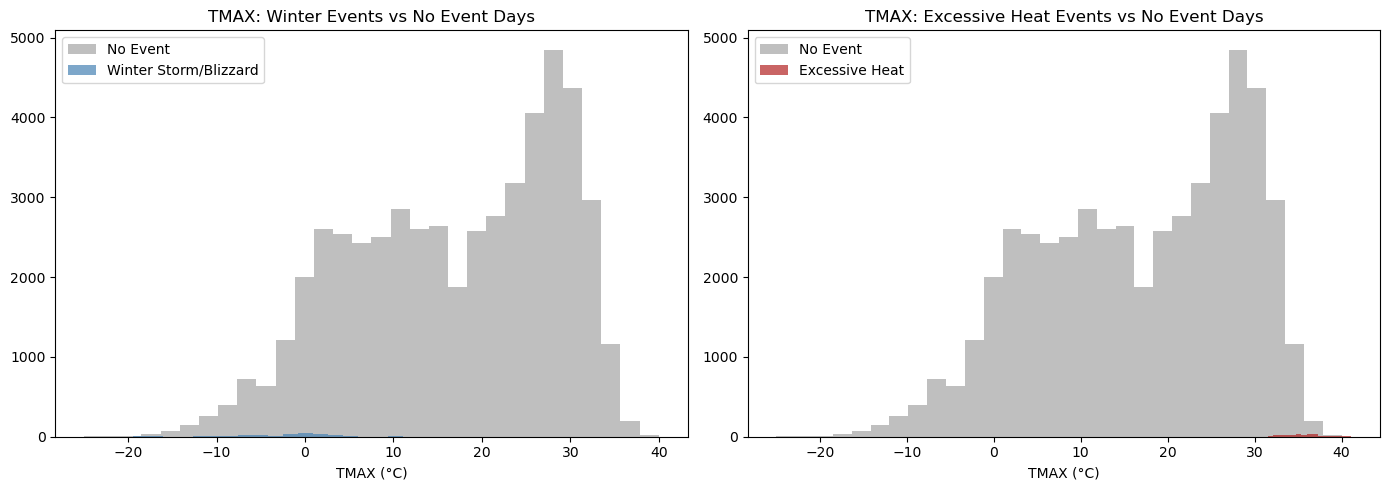

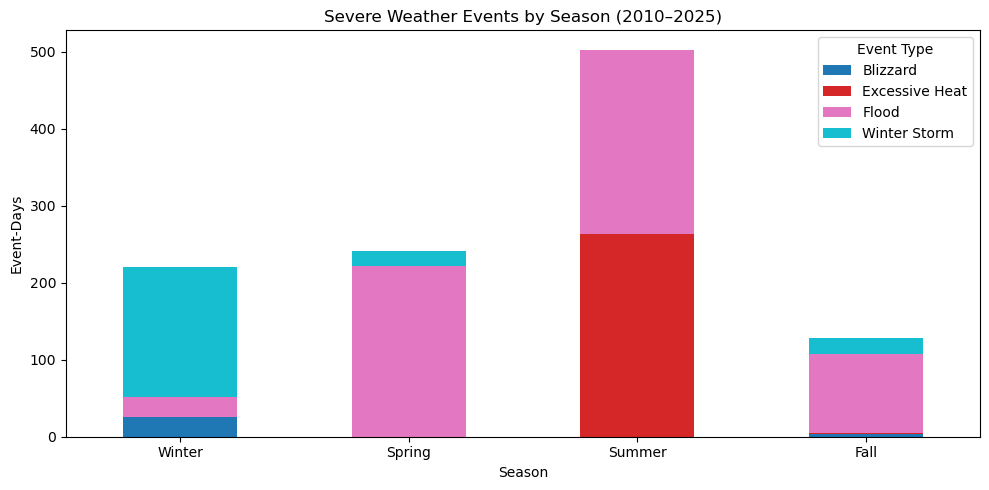

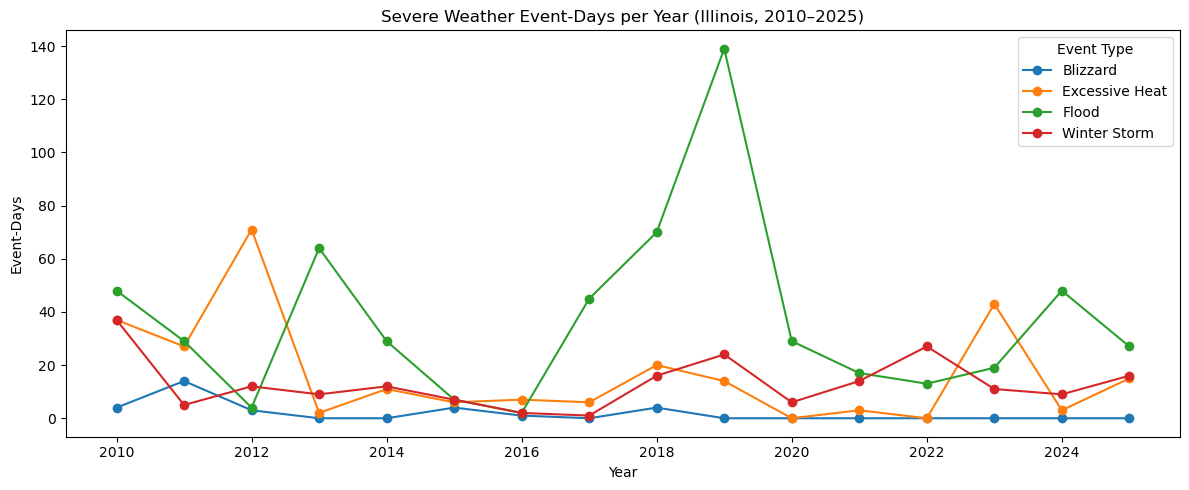

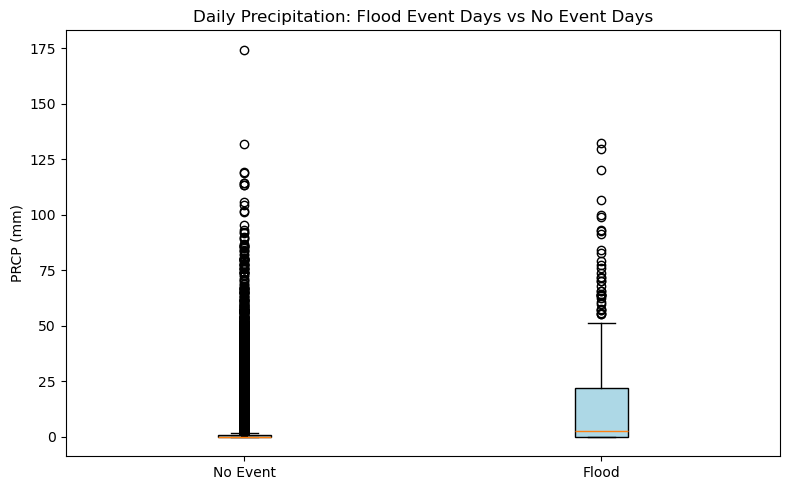

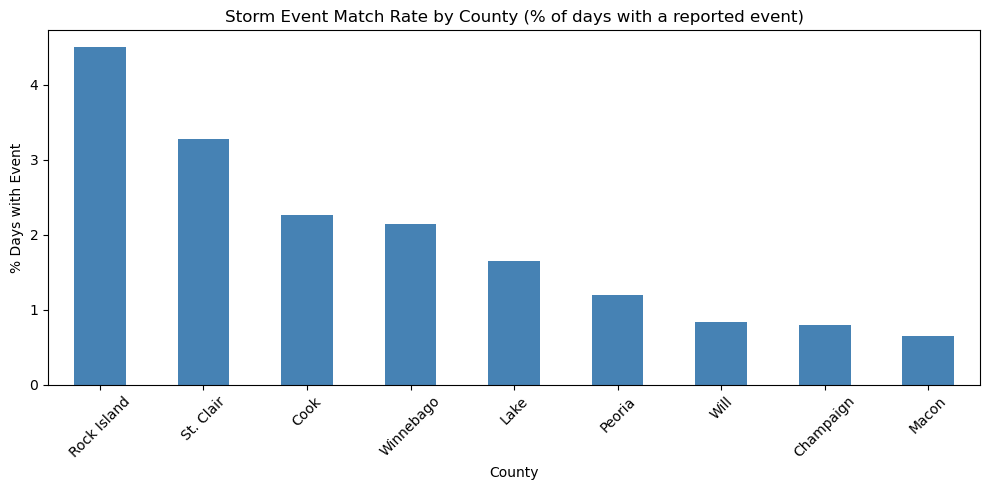

In [74]:
df = pd.read_csv("final_integrated_illinois_climate_events.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
events = df[df["EVENT_TYPE"] != "No Event"]

# ── 1. Temperature distribution: event days vs normal days ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TMAX on winter event days vs non-event days
winter_events = df[df["EVENT_TYPE"].isin(["Winter Storm", "Blizzard"])]
no_event = df[df["EVENT_TYPE"] == "No Event"]
axes[0].hist(no_event["TMAX"].dropna(), bins=30, alpha=0.5, label="No Event", color="gray")
axes[0].hist(winter_events["TMAX"].dropna(), bins=20, alpha=0.7, label="Winter Storm/Blizzard", color="steelblue")
axes[0].set_title("TMAX: Winter Events vs No Event Days")
axes[0].set_xlabel("TMAX (°C)")
axes[0].legend()

# TMAX on Excessive Heat days
heat_events = df[df["EVENT_TYPE"] == "Excessive Heat"]
axes[1].hist(no_event["TMAX"].dropna(), bins=30, alpha=0.5, label="No Event", color="gray")
axes[1].hist(heat_events["TMAX"].dropna(), bins=20, alpha=0.7, label="Excessive Heat", color="firebrick")
axes[1].set_title("TMAX: Excessive Heat Events vs No Event Days")
axes[1].set_xlabel("TMAX (°C)")
axes[1].legend()
plt.tight_layout()
plt.savefig("viz_temp_event_vs_nonevent.png", dpi=150)
plt.show()

# ── 2. Events by season (shows alignment with climate) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
season_event = events.groupby(["SEASON", "EVENT_TYPE"]).size().unstack(fill_value=0)
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_event = season_event.reindex(season_order)
season_event.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Severe Weather Events by Season (2010–2025)")
ax.set_xlabel("Season")
ax.set_ylabel("Event-Days")
ax.legend(title="Event Type", bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("viz_events_by_season.png", dpi=150)
plt.show()

# ── 3. Yearly trend of event counts ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
yearly = events.groupby(["YEAR", "EVENT_TYPE"]).size().unstack(fill_value=0)
yearly.plot(ax=ax, marker="o")
ax.set_title("Severe Weather Event-Days per Year (Illinois, 2010–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Event-Days")
ax.legend(title="Event Type")
plt.tight_layout()
plt.savefig("viz_yearly_trend.png", dpi=150)
plt.show()

# ── 4. Flood days: measured precipitation ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
flood = df[df["EVENT_TYPE"] == "Flood"]["PRCP"].dropna()
no_event_prcp = df[df["EVENT_TYPE"] == "No Event"]["PRCP"].dropna()
ax.boxplot([no_event_prcp, flood], tick_labels=["No Event", "Flood"], patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_title("Daily Precipitation: Flood Event Days vs No Event Days")
ax.set_ylabel("PRCP (mm)")
plt.tight_layout()
plt.savefig("viz_flood_prcp.png", dpi=150)
plt.show()

# ── 5. Event match rate by county ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
county_total = df.groupby("COUNTY").size()
county_events = events.groupby("COUNTY").size()
match_rate = (county_events / county_total * 100).fillna(0).sort_values(ascending=False)
match_rate.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Storm Event Match Rate by County (% of days with a reported event)")
ax.set_xlabel("County")
ax.set_ylabel("% Days with Event")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("viz_match_rate_by_county.png", dpi=150)
plt.show()